# **Top-K Backtest**

### Create DuckDB Connection

In [17]:
import duckdb
import os

DB_FOLDER = "database"
DB_PATH = os.path.join(DB_FOLDER, "cse_data.db")

con = duckdb.connect(database=DB_PATH)

In [28]:
import pandas as pd

pd.set_option('display.max_columns', None)

df = con.execute("""SELECT * FROM stocks_10d_prob_table""").fetch_df()
df.tail()

,company,symbol,volume,trades,prev_close,open,high,low,close,change,change_percentage,date,dup_index,close_1d,close_3d,close_5d,close_10d,close_20d,close_60d,high_20,low_20,std_vol_20,ret_1,ret_3,ret_5,ret_10,ret_20,ret_60,std_close_5,std_close_10,std_close_20,range_5,atr_14,TR,volume_ratio,volume_z,avg_vol_10,avg_vol_20,liquidity_score,ma_ratio_5,ma_ratio_10,ma_ratio_20,price_position,breakout_flag,momentum_score,volatility_score,turnover_ratio,trend_angle,range_position,liquidity_rank,future_close_10d,future_return_10d,target_buy_10d,prob
11781,VIDULLANKA PLC,VLL.X0000,56783,74,17.3,17.3,17.3,16.0,16.5,-0.8,-4.62,2026-03-09,1,17.3,17.8,17.8,18.0,18.3,NaN,18.9,16.5,29943.196724,-0.046243,-0.073034,-0.073034,-0.083333,-0.098361,NaN,0.554076,0.504315,0.555807,2.4,0.457143,1.3,3.389655,1.336903,21993.0,16751.85,4.531641,0.949367,0.932730,0.913874,-0.388889,0,-0.061698,0.539494,0.001303,-0.083835,0.000,207.0,NaN,NaN,0,0.064584
11782,VIDULLANKA PLC,VLL.X0000,12061,23,16.5,16.9,18.0,16.9,17.4,0.9,5.45,2026-03-10,1,16.5,17.4,17.9,18.0,18.9,NaN,18.9,16.5,29833.128650,0.054545,0.000000,-0.027933,-0.033333,-0.079365,NaN,0.476445,0.498999,0.536656,2.4,0.521429,1.5,0.704580,-0.169510,22248.6,17118.00,0.119433,1.006944,0.986954,0.967742,0.466667,0,0.012226,0.495254,0.001907,-0.079850,0.375,207.0,NaN,NaN,0,0.093279
11783,VIDULLANKA PLC,VLL.X0000,9774,19,17.4,17.6,17.6,16.5,16.5,-0.9,-5.17,2026-03-11,1,17.4,17.3,17.8,18.1,18.6,NaN,18.9,16.5,29875.625760,-0.051724,-0.046243,-0.073034,-0.088398,-0.112903,NaN,0.476445,0.581282,0.609465,2.0,0.564286,1.1,0.579889,-0.237014,22998.0,16854.95,0.137442,0.969448,0.944476,0.923077,0.166667,0,-0.065452,0.534500,0.001944,-0.091203,0.000,207.0,NaN,NaN,0,0.289026
11784,VIDULLANKA PLC,VLL.X0000,30359,64,16.7,16.4,16.5,15.0,15.9,-0.8,-4.79,2026-03-13,1,16.5,16.5,17.4,18.2,18.9,NaN,18.5,15.9,29806.552350,-0.036364,-0.036364,-0.086207,-0.126374,-0.158730,NaN,0.626099,0.702693,0.705523,3.0,0.635714,1.5,1.661449,0.405495,25468.2,18272.60,0.673709,0.950957,0.922274,0.897038,-0.034483,0,-0.069319,0.664962,0.002108,-0.103233,0.000,203.0,NaN,NaN,0,0.159599
11785,VIDULLANKA PLC,VLL.X0000,4076,8,15.3,15.0,16.0,15.0,15.3,0.0,0.00,2026-03-19,1,15.9,17.4,17.3,17.9,18.5,NaN,18.4,15.3,29811.083667,-0.037736,-0.120690,-0.115607,-0.145251,-0.172973,NaN,0.782304,0.887944,0.865281,3.0,0.707143,1.0,0.223177,-0.475914,25780.5,18263.50,0.106213,0.937500,0.901060,0.871050,0.081081,0,-0.082600,0.830591,0.001963,-0.125639,0.000,200.0,NaN,NaN,0,0.132885


#### Calculate daily return
- For each day, calculate the average future 10-day return of the top 10 stocks
- This gives a daily portfolio return, assuming equal weighting of the top 10 stocks

In [29]:
# ✅ Line 1
# con → your database connection (DuckDB / SQLite / etc.)
# .execute(""" ... """) → runs a SQL query
# The result will be converted later to a dataframe

# ✅ Line 2
# WITH → creates a temporary table (CTE = Common Table Expression)
# ranked → name of that temporary table
# 👉 Think:
# "First, create a table called ranked"


# Line 3–4
# SELECT * → take all columns from the original table

# ✅ Line 5
# This is the MOST IMPORTANT LINE
# ROW_NUMBER() → gives ranking numbers: 1, 2, 3, 4...
# OVER (...) → defines how ranking is done
# Inside:
# PARTITION BY date
# 👉 group rows by each date
# ORDER BY prob DESC
# 👉 inside each date, sort by prob (highest first)
# AS rn → store result in column rn

# ✅ Line 6
# Source table
# This contains:
# date
# prob
# future_return_10d
# other features

- date	: The trading day for the Top-K evaluation
- daily_return	: The average return of the top 10 stocks for that day
- equity	: The cumulative value of your investment, starting from invesement = 1

In [30]:
# Invesement money
invesement= 1

# Connect to an in-memory DuckDB database
con = duckdb.connect(database=DB_PATH)

# Pull Results Back into Python & Equity Curve
# For each date, it ranks the stocks by probability (prob) in descending order
# ROW_NUMBER() assigns 1 to the highest-probability stock, 2 to the next, and so on
# WHERE rn <= 10 AND future_return_10d IS NOT NULL
#       Filters only the top 10 stocks per day (rn <= 10)
#       Ignores rows where the future_return_10d is missing.


# - ROW_NUMBER() → is a SQL window function that assigns a unique number to each row within a group.
# - PARTITION BY date → means the numbering resets for each date. So for every single trading day, we start counting from 1.
# - ORDER BY prob DESC → means the row with the highest probability of profit gets rn = 1, the next highest gets rn = 2, and so on.
# - AS rn → stores this number in a new column called rn.

daily_returns_df = con.execute("""
    WITH ranked AS (
        SELECT
            *,
        ROW_NUMBER() OVER (PARTITION BY date ORDER BY prob DESC) AS rn
        FROM stocks_10d_prob_table
    ),
    topk AS (
        SELECT *
        FROM ranked
        WHERE rn <= 10 AND future_return_10d IS NOT NULL
    )
    SELECT
        date,
        AVG(future_return_10d) AS daily_return
    FROM topk
    GROUP BY date
    ORDER BY date
""").df()

# Compute equity curve in Python
# The total value of your ownership (your money invested + profit/loss)
# Cumulative investment
daily_returns_df['equity'] = (invesement + daily_returns_df['daily_return']).cumprod()

daily_returns_df.tail()

,date,daily_return,equity
27,2026-02-20,0.078466,690.572082
28,2026-02-23,0.198854,827.894801
29,2026-02-24,0.198722,992.415546
30,2026-02-25,0.117142,1108.669132
31,2026-02-26,-0.041807,1062.318697


### Check all tables in DuckDB

In [31]:
tables = con.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
""").fetch_df()

print(tables)

                           table_name
0                    raw_stocks_table
1               stocks_10d_prob_table
2                  stocks_clean_table
3         stocks_features_clean_table
4   stocks_features_labeled_10d_table
5               stocks_features_table
6                 stocks_sorted_table
7                        stocks_table
8             temp_future_price_table
9                temp_liquidity_table
10                 temp_returns_table
11                   temp_trend_table
12                      temp_tr_table
13                     temp_vol_table


### Performance Metrics for top 10 stocks all day
- All the metrics calculated — **Total Return**, **Sharpe Ratio**, **Win Rate**, **Max Drawdown**, etc. — are based only on the top 10 stocks per day that our strategy selected
- This is helpfull to us to get idea about how our model predicted top 10 stock were formanced we can trust thr model
- Not reccomended, but if we insvested in all these 10 stock every day we have thi return

In [33]:
# equity = your portfolio growth over time
# Takes the last value of equity, Subtracts 1 (initial capital)
total_return = (daily_returns_df['equity'].iloc[-1] - invesement ) * 100

# Mean = average of all daily profit/loss
# how much you make per day
avg_return = daily_returns_df['daily_return'].mean()

# Standard deviation of daily returns
# How much your returns move up and down
# High volatility = risky (big swings)   &   Low volatility = stable
# How far returns are spread from average >>> 1% ok more than 5% not good
volatility = daily_returns_df['daily_return'].std()

# Why 252?   Because stock market has about 252 trading days per year.
# We multiply by √252 to convert daily Sharpe → yearly Sharpe
# What Sharpe means : Return per unit of risk
# How much return you are getting for the risk you are taking
# Higher = better
# < 1 → weak , 1–2 → good , 2–3 → strong , 3+ → very strong , 5+ → suspiciously strong
sharpe = avg_return / volatility * (252 ** 0.5)

# Check if each day return > 0 >>> This becomes True (1) or False (0) >>> Take mean
# How often you win
win_rate = (daily_returns_df['daily_return'] > 0).mean() * 100

# Biggest loss from peak to bottom
# cummax() >>> Gets highest equity reached so far
# equity / cummax() >>> How far below peak you are
# - 1 >>> Convert to percentage drop
# .min() >>> Get worst drop
max_drawdown = ((daily_returns_df['equity'] / daily_returns_df['equity'].cummax()) - 1).min()

print(f"Total Return : {total_return:.2f}%")
print(f"Avg Return : {avg_return:.2f}%")
print(f"Volatility : {volatility:.2f}")
print(f"Sharpe Ratio : {sharpe:.3f}")
print(f"Win Rate : {win_rate:.3f}%")
print(f"Max Drawdown : {max_drawdown:.3f}")

Total Return : 106131.87%
Avg Return : 0.25%
Volatility : 0.14
Sharpe Ratio : 29.403
Win Rate : 93.750%
Max Drawdown : -0.070


## Profit / Loss from a prticular day

In [34]:
import numpy as np
import pandas as pd

def evaluate_strategy(start_date):

    # Filter from start date if provided

    df = daily_returns_df.copy()

    df['date'] = pd.to_datetime(df['date'])

    if start_date is not None:
        start_date = pd.to_datetime(start_date)
        df = df[df['date'] >= start_date].copy()
        
    # Check if filtered data is empty
    if df.empty:
        print(f"No data available from {start_date.date()}")
        return None
        
    total_return = (df['equity'].iloc[-1] - invesement ) * 100
    avg_return = df['daily_return'].mean()

    sharpe = 0
    if volatility != 0:
        sharpe = avg_return / volatility * np.sqrt(252)
        
    win_rate = (df['daily_return'] > 0).mean() * 100
    max_drawdown = ((df['equity'] / df['equity'].cummax()) - 1).min()

    results = {
        "Total Return from ": total_return,
        "Sharpe Ratio": sharpe,
        "Win Rate": win_rate,
        "Max Drawdown": max_drawdown
    }

    return results

# Shwoing
start_date="2025-11-18"
metrics = evaluate_strategy(start_date = start_date)

print("From : ", start_date, " to today\n")

if metrics is not None:
    for k, v in metrics.items():
        if "Return" in k or "Drawdown" in k or "Rate" in k:
            print(f"{k}: {v:.2%}")
        else:
            print(f"{k}: {v:.2f}")
else:
    print("No metrics to show because there is no data for this start date.")

From :  2025-11-18  to today

Total Return from : 10613186.97%
Sharpe Ratio: 29.40
Win Rate: 9375.00%
Max Drawdown: -7.01%


In [35]:
# print(features_labeled_10d_df['future_return_10d'].describe())
df = con.execute("""
    SELECT 
        symbol,
        future_return_10d
    FROM stocks_10d_prob_table
    LIMIT 5
""").fetch_df()

df

,symbol,future_return_10d
0,ABAN.N0000,0.042894
1,ABAN.N0000,-0.068916
2,ABAN.N0000,-0.085536
3,ABAN.N0000,-0.068269
4,ABAN.N0000,-0.084181


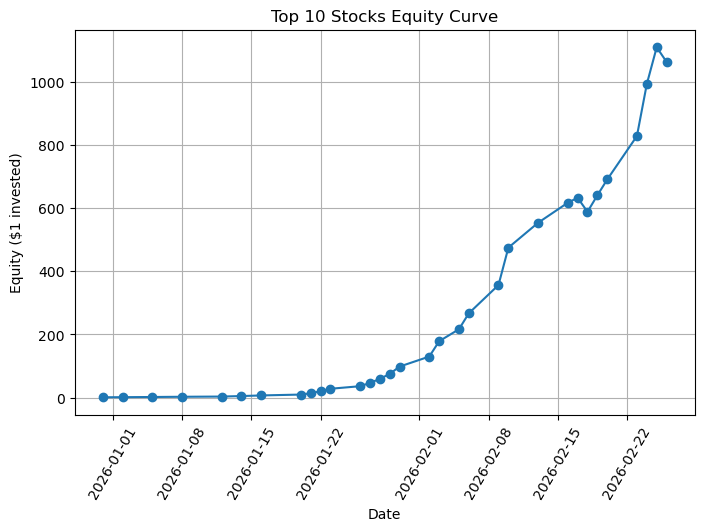

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(daily_returns_df['date'], daily_returns_df['equity'], marker='o')
plt.title("Top 10 Stocks Equity Curve")

plt.xlabel("Date")
plt.ylabel("Equity ($1 invested)")

plt.xticks(rotation=60)

plt.grid(True)
plt.show()

## Top 10 stocks
- List the top 10 stock for each day by "prob" value

In [41]:
# PARTITION BY date >>> This means “start a new ranking for each date.”
# ORDER BY prob DESC >>> Within that date, sort all stocks by model probability (prob) from highest to lowest
# ROW_NUMBER() >>> Assigns a sequential number starting from 1
# The highest probability stock of that day gets rank=1, second highest gets rank=2, …
# WHERE rank <= 10 >>> only want the Top 10 highest probability stocks for each date

topk_companies_df = con.execute("""
    WITH ranked AS (
        SELECT
            date,
            company,
            symbol,
            prob,
            ROW_NUMBER() OVER (PARTITION BY date ORDER BY prob DESC) AS rank
        FROM stocks_10d_prob_table
    )
        SELECT *
        FROM ranked
        WHERE rank <= 10
            AND date = (SELECT MAX(date) FROM stocks_10d_prob_table)
        ORDER BY rank
""").df()

topk_companies_df

,date,company,symbol,prob,rank
0,2026-03-19,SOFTLOGIC HOLDINGS PLC,SHL.N0000,0.718361,1
1,2026-03-19,CEYLINCO HOLDINGS PLC,CINS.N0000,0.600507,2
2,2026-03-19,HVA FOODS PLC,HVA.N0000,0.560697,3
3,2026-03-19,WASKADUWA BEACH RESORT PLC,CITW.N0000,0.421218,4
4,2026-03-19,ROYAL PALMS BEACH HOTELS PLC,RPBH.N0000,0.396425,5
5,2026-03-19,LEE HEDGES PLC,SHAW.N0000,0.394060,6
6,2026-03-19,KEELLS FOOD PRODUCTS PLC,KFP.N0000,0.382443,7
7,2026-03-19,MYLAND DEVELOPMENTS PLC,MDL.N0000,0.373304,8
8,2026-03-19,KERNER HAUS GLOBAL SOLUTIONS PLC,CPRT.N0000,0.346499,9
9,2026-03-19,HNB FINANCE PLC,HNBF.N0000,0.344582,10


### Close DuckDB Connection

In [41]:
if 'con' in globals():  # Check if connection exists
    try:
        con.close()        # Close it
        print("DuckDB connection closed.")
    except Exception as e:
        print("Error closing DuckDB:", e)
    finally:
        del con             # Delete the variable from memory

DuckDB connection closed.
